# Fig. 6 and S6: trimodal TEA-seq with a held-out well

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ashford-A/UniVI/blob/main/docs/reproducibility/api/fig6_teaseq.ipynb)

RNA, surface protein, and chromatin accessibility measured in the same cells (Swanson et al. 2021). UniVI is trained on wells 3, 4 and 6 and evaluated on well 5, with every preprocessing step fit on the training wells. Model settings follow the archived notebook `UniVI_manuscript_GR-Figure__6__TEA-seq_tri-modal.ipynb`; preprocessing uses UniVI's fitted preprocessors, so results will be close to, not identical with, the published ones.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q "univi[tutorials]>=1.1" "pandas==2.2.3"

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import torch

import univi.datasets as uds
from univi import ModalityConfig, TrainingConfig, UniVIConfig, UniVIMultiModalVAE, UniVITrainer
from univi.evaluation import compute_foscttm, encode_adata, encode_fused_adata_pair
from univi.preprocessing import ADTPreprocessor, ATACPreprocessor, RNAPreprocessor
from univi.utils.seed import set_seed
from univi.workflows import make_loader, stack_embeddings

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
set_seed(0)

C:\Users\ashfo\micromamba\envs\univi-release-050\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
N_EPOCHS = 3000       # archived notebook: 3000 with early stopping (patience 200)
N_HVG = 2000
N_LSI = 100
HOLDOUT = "GSM5123953_X066-MP0C1W5_leukopak_perm-cells_tea"   # well 5
LEIDEN_RESOLUTION = 0.8

## Data and well hold-out

The ATAC modality is a genome-wide tile matrix (500 bp tiles). Tiles open in 0.5–80% of training cells are kept. A random 10% of training-well cells is used for early stopping.

In [4]:
data = uds.load("teaseq_pbmc")
rna, adt, atac = data["rna"], data["adt"], data["atac"]
well = rna.obs["sample_id"].astype(str).to_numpy()
held = np.flatnonzero(well == HOLDOUT)
rest = np.random.default_rng(0).permutation(np.flatnonzero(well != HOLDOUT))
splits = {"train": np.sort(rest[len(rest) // 10:]), "val": np.sort(rest[: len(rest) // 10]), "test": held}
print({k: len(v) for k, v in splits.items()})

rna_prep = RNAPreprocessor(n_hvg=N_HVG, scale=True).fit(rna[splits["train"]])
adt_prep = ADTPreprocessor(scale=True).fit(adt[splits["train"]])
atac_prep = ATACPreprocessor(n_components=N_LSI, drop_first=False, scale=True,
                             min_fraction=0.005, max_fraction=0.80).fit(atac[splits["train"]])
parts = {k: {"rna": rna_prep.transform(rna[i]), "adt": adt_prep.transform(adt[i]), "atac": atac_prep.transform(atac[i])}
         for k, i in splits.items()}

teaseq_pbmc_rna.h5ad: 100%|██████████| 76.5M/76.5M [00:46<00:00, 1.64MB/s]
teaseq_pbmc_adt.h5ad: 100%|██████████| 4.67M/4.67M [00:06<00:00, 682kB/s]
teaseq_pbmc_atac.h5ad: 100%|██████████| 339M/339M [03:05<00:00, 1.82MB/s] 


{'train': 20226, 'val': 2247, 'test': 7421}


In [5]:
cfg = UniVIConfig(
    latent_dim=30, beta=1.15,
    gamma=1.45,  # value in the archived notebook; Supplemental Table S8 lists 1.35
    encoder_dropout=0.10, decoder_dropout=0.0,
    kl_anneal_start=0, kl_anneal_end=50, align_anneal_start=25, align_anneal_end=75,
    modalities=[
        ModalityConfig("rna", parts["train"]["rna"].n_vars, [512, 256, 128], [128, 256, 512], likelihood="gaussian"),
        ModalityConfig("adt", parts["train"]["adt"].n_vars, [128, 64], [64, 128], likelihood="gaussian"),
        ModalityConfig("atac", parts["train"]["atac"].n_vars, [128, 64], [64, 128], likelihood="gaussian"),
    ],
)
model = UniVIMultiModalVAE(cfg, loss_mode="v1", v1_recon="avg", normalize_v1_terms=True)
UniVITrainer(
    model, make_loader(parts["train"], batch_size=256, shuffle=True, drop_last=True),
    make_loader(parts["val"], batch_size=1024),
    TrainingConfig(n_epochs=N_EPOCHS, batch_size=256, lr=1e-4, weight_decay=1e-4, device=device,
                   early_stopping=True, patience=200, best_epoch_warmup=75, log_every=100),
).fit();

[2026-09-21 16:17:05,767] [UniVITrainer] [INFO] TrainingConfig:
[2026-09-21 16:17:05,768] [UniVITrainer] [INFO]   n_epochs: 3000
[2026-09-21 16:17:05,768] [UniVITrainer] [INFO]   batch_size: 256
[2026-09-21 16:17:05,768] [UniVITrainer] [INFO]   lr: 0.0001
[2026-09-21 16:17:05,769] [UniVITrainer] [INFO]   weight_decay: 0.0001
[2026-09-21 16:17:05,769] [UniVITrainer] [INFO]   device: 'cuda'
[2026-09-21 16:17:05,770] [UniVITrainer] [INFO]   log_every: 100
[2026-09-21 16:17:05,770] [UniVITrainer] [INFO]   grad_clip: None
[2026-09-21 16:17:05,770] [UniVITrainer] [INFO]   num_workers: 0
[2026-09-21 16:17:05,771] [UniVITrainer] [INFO]   seed: 0
[2026-09-21 16:17:05,771] [UniVITrainer] [INFO]   early_stopping: True
[2026-09-21 16:17:05,772] [UniVITrainer] [INFO]   patience: 200
[2026-09-21 16:17:05,772] [UniVITrainer] [INFO]   min_delta: 0.0
[2026-09-21 16:17:05,773] [UniVITrainer] [INFO]   best_epoch_warmup: 75
Training UniVI:   0%|          | 0/3000 [00:00<?, ?it/s][2026-09-21 16:17:09,793] 

## Held-out well: alignment between all three modalities

In [6]:
test = parts["test"]
z = {m: encode_adata(model, a, modality=m, device=device, latent="modality_mean") for m, a in test.items()}
pd.Series({f"FOSCTTM {a}–{b}": compute_foscttm(z[a], z[b])
           for a, b in [("rna", "adt"), ("rna", "atac"), ("adt", "atac")]}).round(3)

FOSCTTM rna–adt     0.075
FOSCTTM rna–atac    0.049
FOSCTTM adt–atac    0.081
dtype: float64

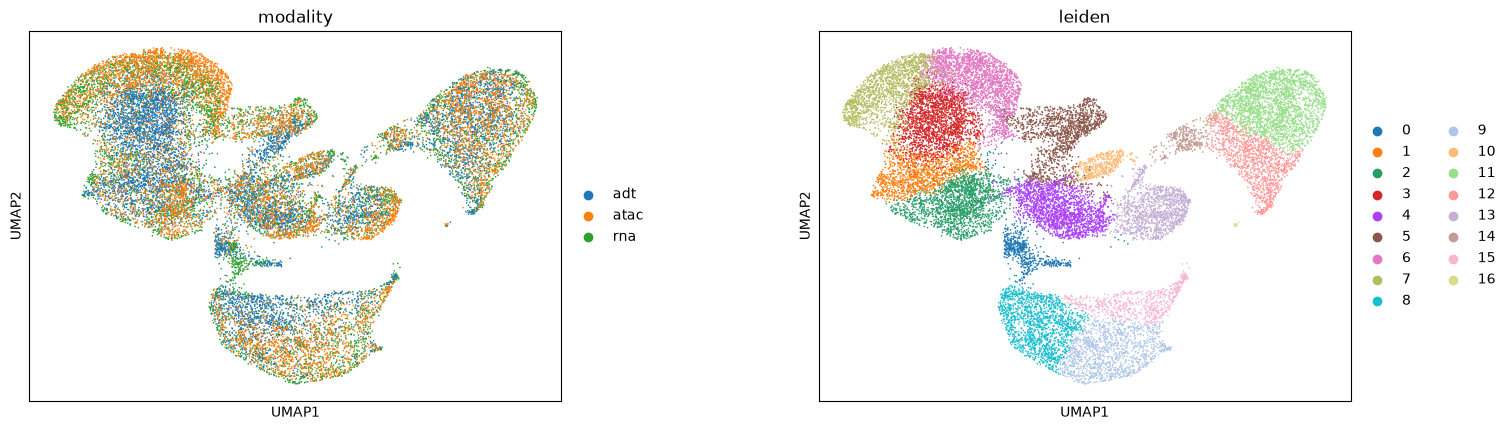

modality,adt,atac,rna
leiden,,,
0,0.43,0.07,0.50
1,0.51,0.22,0.27
2,0.30,0.35,0.34
3,0.72,0.13,0.15
4,0.38,0.32,0.29
5,0.31,0.32,0.36
6,0.07,0.52,0.41
7,0.11,0.43,0.46
8,0.48,0.26,0.26


In [7]:
joint = stack_embeddings(model, [("well5", m, a) for m, a in test.items()], device=device)
sc.pp.neighbors(joint, use_rep="X_univi", n_neighbors=30)
sc.tl.leiden(joint, resolution=LEIDEN_RESOLUTION, key_added="leiden", flavor="igraph", n_iterations=2)
sc.tl.umap(joint, random_state=0)
sc.pl.umap(joint, color=["modality", "leiden"], wspace=0.35)
pd.crosstab(joint.obs["leiden"], joint.obs["modality"], normalize="index").round(2)

## Marker concordance on the fused embedding (Supplemental Fig. S6)

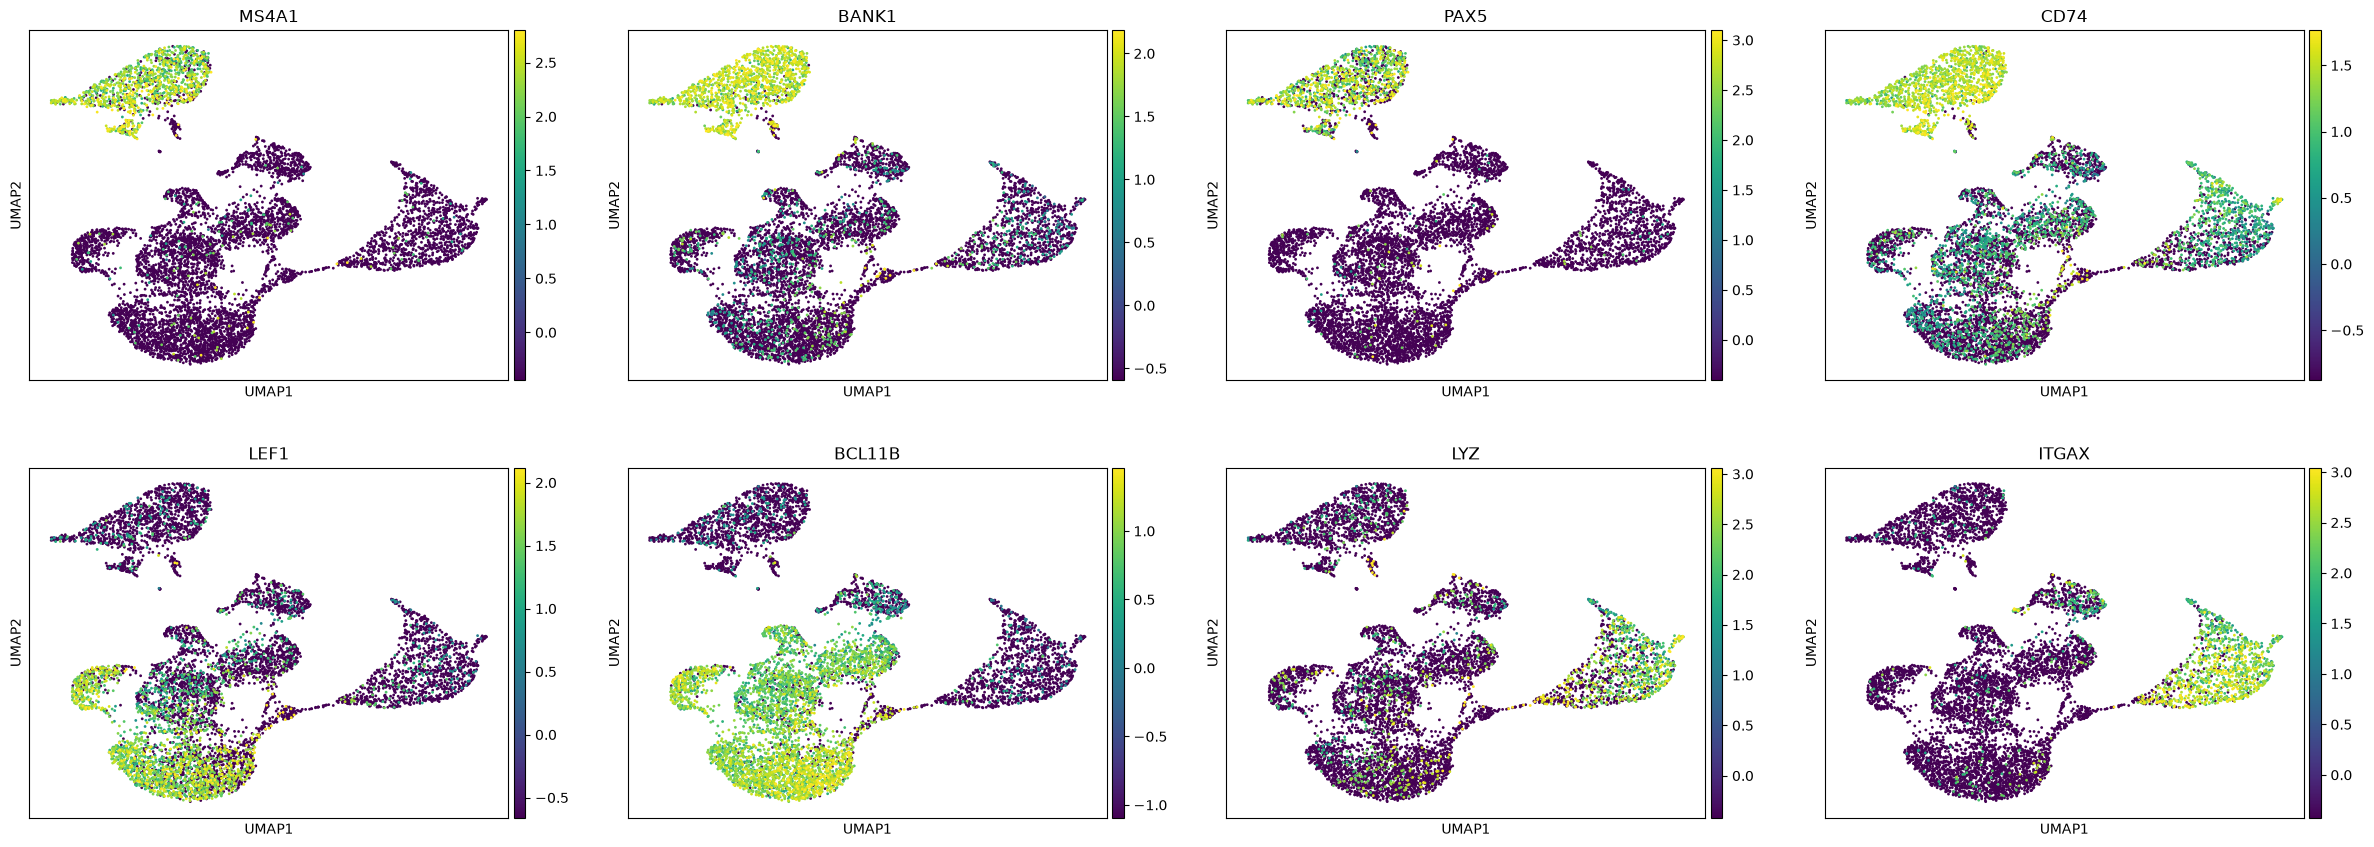

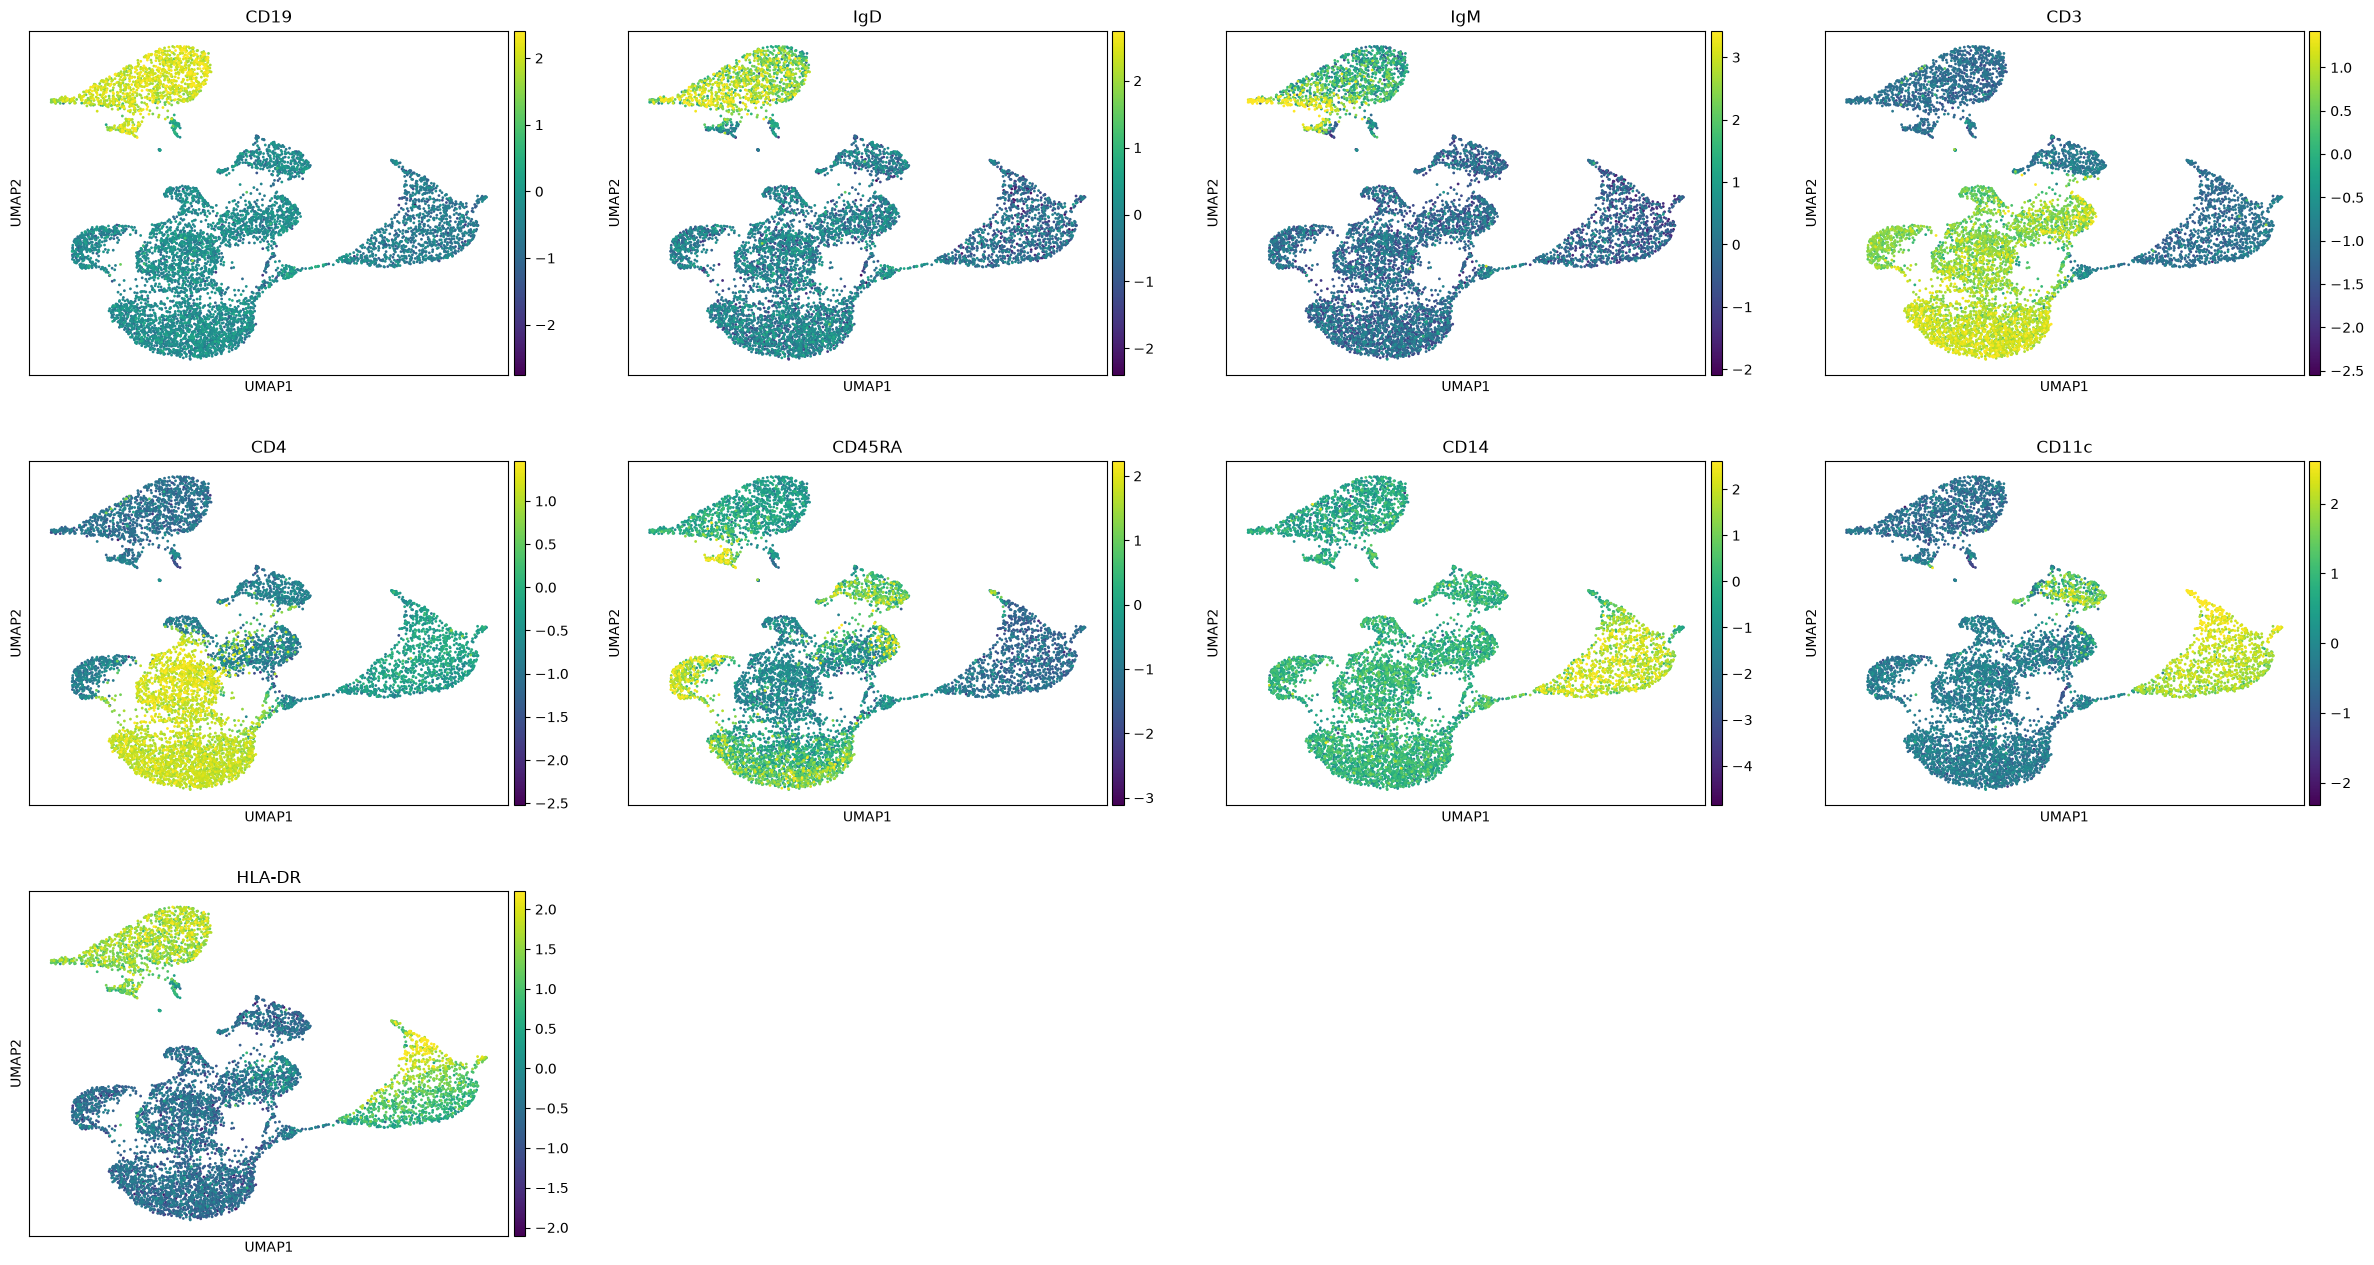

In [8]:
encode_fused_adata_pair(model, adata_by_mod=test, device=device, fused_obsm_key="X_univi_fused")
r, p = test["rna"], test["adt"]
sc.pp.neighbors(r, use_rep="X_univi_fused", n_neighbors=30)
sc.tl.umap(r, random_state=0)
p.obsm["X_umap"] = r.obsm["X_umap"]
genes = [g for g in ["MS4A1", "BANK1", "PAX5", "CD74", "LEF1", "BCL11B", "LYZ", "ITGAX"] if g in r.var_names]
proteins = [q for q in ["CD19", "IgD", "IgM", "CD3", "CD4", "CD45RA", "CD14", "CD11c", "HLA-DR"] if q in p.var_names]
sc.pl.umap(r, color=genes, ncols=4, vmax="p99", cmap="viridis")
sc.pl.umap(p, color=proteins, ncols=4, vmax="p99", cmap="viridis")